# Individual Task – Alif  
## Breast Cancer Prediction using Logistic Regression

This notebook is rebuilt to follow the individual task rubric:
1. Problem framing and data understanding  
2. Model implementation and technical accuracy  
3. Evaluation and interpretation  
4. Reasoning and justification  
5. Visual presentation of results  
6. Clear result interpretation

## 1. Problem Framing

**Real-world problem:** Breast cancer diagnosis is an important healthcare classification problem.  
The goal is to predict whether a tumor is **Benign (0)** or **Malignant (1)** based on cell nucleus measurements.

**Machine Learning task:** Supervised binary classification.  
**Main model for Alif:** Logistic Regression.  
**Reason:** Logistic Regression is suitable for binary classification, interpretable, and allows feature importance analysis through model coefficients.

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42

## 2. Load Dataset

This cell supports two options:
- If you upload `data ML .csv`, it will use your uploaded dataset.
- If no CSV is available, it will use the built-in Breast Cancer Wisconsin dataset from scikit-learn so the notebook can still run.

In [ ]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

csv_candidates = [
    "data ML .csv",
    "data ML.csv",
    "breast_cancer.csv",
    "data.csv"
]

csv_file = None
for file in csv_candidates:
    if os.path.exists(file):
        csv_file = file
        break

# Google Colab upload support
if csv_file is None:
    try:
        from google.colab import files
        print("Please upload your dataset CSV file, e.g. data ML .csv")
        uploaded = files.upload()
        if len(uploaded) > 0:
            csv_file = list(uploaded.keys())[0]
    except Exception:
        pass

if csv_file is not None:
    df = pd.read_csv(csv_file)
    dataset_source = f"Uploaded CSV: {csv_file}"
else:
    cancer = load_breast_cancer()
    df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    # scikit-learn target: 0 = malignant, 1 = benign
    # Convert to assignment convention: 1 = malignant, 0 = benign
    df["diagnosis"] = 1 - cancer.target
    dataset_source = "Built-in scikit-learn Breast Cancer Wisconsin dataset"

print("Dataset source:", dataset_source)
display(df.head())

Dataset source: Uploaded CSV: data ML .csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Data Understanding and Exploration

This section checks dataset size, feature types, missing values, duplicates, target distribution, and basic statistics.

In [ ]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum().to_frame("missing_count"))

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (569, 33)

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Missing Values:


,missing_count
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0



Duplicate Rows: 0


In [ ]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

df = df.copy()
df = df.drop_duplicates()

# Remove unnecessary index/id columns if they exist
for col in ["id", "ID", "Unnamed: 32", "Unnamed: 0"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Identify target column
possible_targets = ["diagnosis", "target", "class", "label"]
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("No target column found. Please ensure the dataset has diagnosis/target/class/label column.")

# Convert diagnosis labels if needed
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].astype(str).str.strip().map({
        "M": 1, "Malignant": 1, "malignant": 1,
        "B": 0, "Benign": 0, "benign": 0
    })

# Final check
if df[target_col].isnull().any():
    raise ValueError("Target column contains unmapped or missing values. Please check target labels.")

print("Cleaned Dataset Shape:", df.shape)
print("Target Column:", target_col)
display(df.head())

Cleaned Dataset Shape: (569, 31)
Target Column: diagnosis


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count
diagnosis,
0,357
1,212


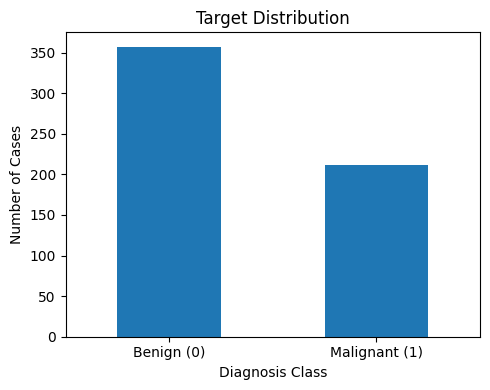

Class percentage:


,percentage
diagnosis,
0,62.74
1,37.26


In [ ]:
# ============================================================
# 5. TARGET DISTRIBUTION VISUAL
# ============================================================

target_counts = df[target_col].value_counts().sort_index()
display(target_counts.to_frame("count"))

plt.figure(figsize=(5, 4))
target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Cases")
plt.xticks([0, 1], ["Benign (0)", "Malignant (1)"], rotation=0)
plt.tight_layout()
plt.show()

print("Class percentage:")
display((target_counts / target_counts.sum() * 100).round(2).to_frame("percentage"))

## 4. Feature Selection and Train-Test Split

A 70:30 train-test split is used with stratification to preserve the target class ratio.  
The preprocessing pipeline handles missing values and scaling.

In [ ]:
# ============================================================
# 6. FEATURE AND TARGET SEPARATION
# ============================================================

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Keep only numerical features for Logistic Regression
X = X.select_dtypes(include=[np.number])

print("Number of selected numerical features:", X.shape[1])
print("Target variable:", target_col)
display(X.head())

Number of selected numerical features: 30
Target variable: diagnosis


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (398, 30)
Testing set : (171, 30)

Training target distribution:
diagnosis
0    0.628
1    0.372
Name: proportion, dtype: float64

Testing target distribution:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64


## 5. Main Model Implementation: Logistic Regression

The model is implemented using a pipeline:
1. `SimpleImputer` handles missing values.  
2. `StandardScaler` standardizes features.  
3. `SelectKBest` selects important features.  
4. `LogisticRegression` performs binary classification.

In [ ]:
# ============================================================
# 8. BASELINE LOGISTIC REGRESSION PIPELINE
# ============================================================

baseline_lr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k="all")),
    ("model", LogisticRegression(
        solver="liblinear",
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

baseline_lr_pipeline.fit(X_train, y_train)

baseline_pred = baseline_lr_pipeline.predict(X_test)
baseline_prob = baseline_lr_pipeline.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [ ]:
# ============================================================
# 9. FUNCTION FOR MODEL EVALUATION
# ============================================================

def evaluate_classification_model(model_name, y_true, y_pred, y_prob):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    return results

baseline_results = evaluate_classification_model(
    "Baseline Logistic Regression",
    y_test,
    baseline_pred,
    baseline_prob
)

pd.DataFrame([baseline_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.97076,0.983607,0.9375,0.96,0.997518


In [ ]:
# ============================================================
# 10. BASELINE CLASSIFICATION REPORT
# ============================================================

print("Classification Report - Baseline Logistic Regression")
print(classification_report(
    y_test,
    baseline_pred,
    target_names=["Benign (0)", "Malignant (1)"]
))

Classification Report - Baseline Logistic Regression
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.98       107
Malignant (1)       0.98      0.94      0.96        64

     accuracy                           0.97       171
    macro avg       0.97      0.96      0.97       171
 weighted avg       0.97      0.97      0.97       171



## 6. Visual Evaluation

This section includes the confusion matrix and ROC curve to support the visual presentation requirement.


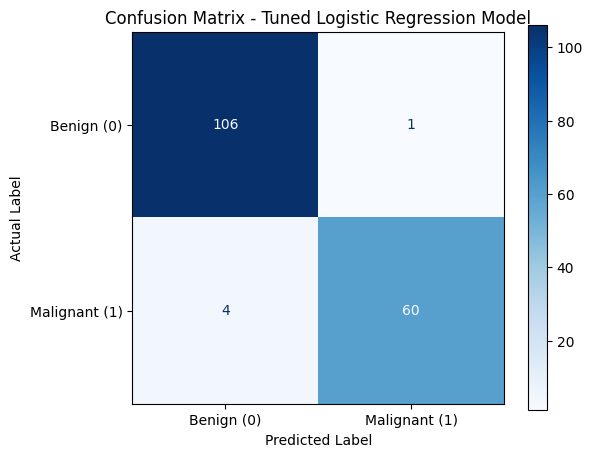

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, baseline_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "Malignant (1)"]
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap="Blues", ax=ax, colorbar=True)

plt.title("Confusion Matrix - Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

<Figure size 600x500 with 0 Axes>

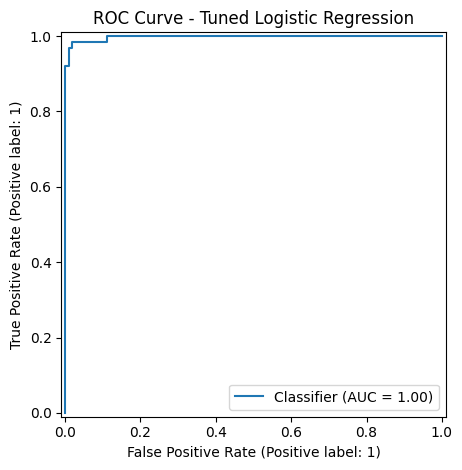

In [ ]:
# ============================================================
# 11. ROC CURVE
# ============================================================

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, baseline_prob)
plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

## 7. Feature Importance

For Logistic Regression, feature importance is interpreted using the absolute coefficient values.  
Higher absolute coefficients indicate stronger influence on the prediction.

In [ ]:
# ============================================================
# 12. FEATURE IMPORTANCE USING LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

# Get selected feature names
selector = baseline_lr_pipeline.named_steps["feature_selection"]
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]

coefficients = baseline_lr_pipeline.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
}).sort_values(by="Absolute Importance", ascending=False)

display(feature_importance.head(10))

,Feature,Coefficient,Absolute Importance
21,texture_worst,1.373999,1.373999
10,radius_se,1.214320,1.214320
28,symmetry_worst,1.077204,1.077204
13,area_se,0.941225,0.941225
15,compactness_se,-0.913868,0.913868
23,area_worst,0.908859,0.908859
7,concave points_mean,0.859029,0.859029
20,radius_worst,0.844973,0.844973
26,concavity_worst,0.831026,0.831026
6,concavity_mean,0.822359,0.822359


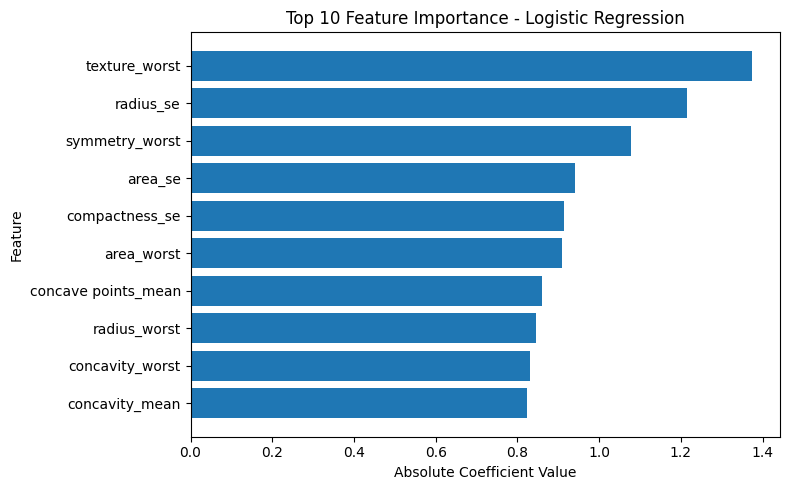

In [ ]:
# ============================================================
# 13. FEATURE IMPORTANCE BAR CHART
# ============================================================

top_features = feature_importance.head(10).sort_values("Absolute Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Absolute Importance"])
plt.title("Top 10 Feature Importance - Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Result Interpretation and Justification

Use this section for your presentation/report.

**Interpretation template:**  
The Logistic Regression model achieved good performance based on accuracy, precision, recall, F1-score, and ROC-AUC. Recall is important in this problem because missing malignant cases can be serious. The confusion matrix shows how many benign and malignant cases were correctly or incorrectly classified. The ROC curve shows that the model separates the two classes well.

**Justification:**  
Logistic Regression was selected because it is suitable for binary classification, easy to interpret, and provides coefficient-based feature importance. StandardScaler was used because Logistic Regression is sensitive to feature scale. The notebook focuses on one main model, which matches the individual task requirement.
